In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
print(f"Total rows: {len(df)}")
print(f"Deck missing %:{round(df['deck'].isnull().sum()/len(df)*100,1)}%")
print(f"Age missing %:{round(df['age'].isnull().sum()/len(df)*100,1)}%")

Total rows: 891
Deck missing %:77.2%
Age missing %:19.9%


In [22]:
#df = df.drop(columns =['deck'])
df['age'] = df['age'].fillna(df['age'].mean())
df = df.dropna(subset = ['embark_town'])
print("Cleaned! remaining missing value:")
print(df.isnull().sum())

Cleaned! remaining missing value:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [25]:
print(df['survived'].value_counts())

survived
0    549
1    340
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

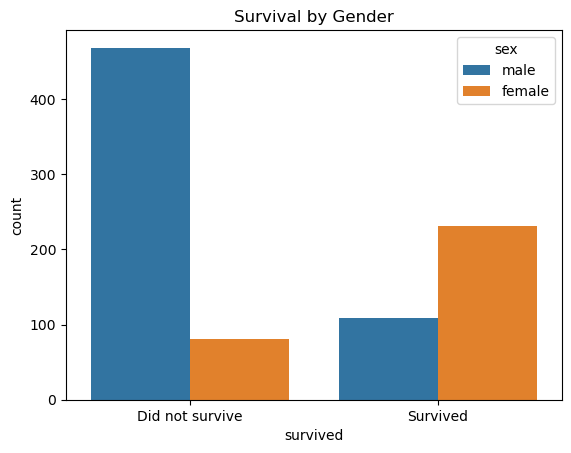

In [27]:
sns.countplot(x='survived',hue='sex',data = df)
plt.title('Survival by Gender')
plt.xticks([0,1],['Did not survive','Survived'])
plt.show

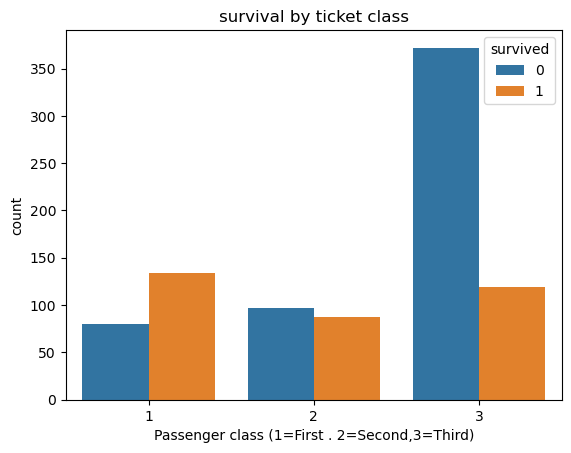

In [28]:
sns.countplot(x='pclass',hue='survived',data = df)
plt.title('survival by ticket class')
plt.xlabel('Passenger class (1=First . 2=Second,3=Third)')
plt.show()

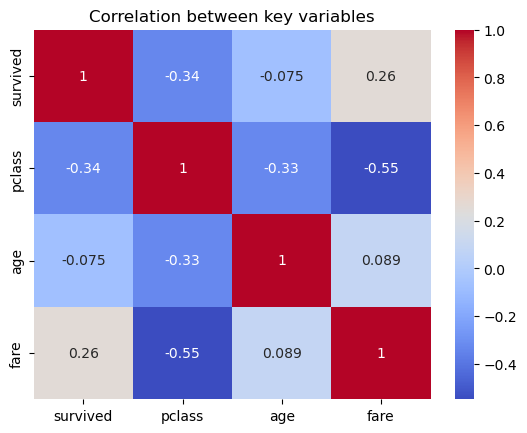

In [31]:
sns.heatmap(df[['survived','pclass','age','fare']].corr(), annot = True , cmap='coolwarm')
plt.title('Correlation between key variables')
plt.show()